In [257]:
using Pkg
Pkg.activate(ENV["PYTHON_JULIAPKG_PROJECT"])
using ReactionMechanismSimulator

  Activating project at `~/mambaforge/envs/rmg_electrocat_2/julia_env`


In [258]:
using PythonPlot
using DifferentialEquations
using Sundials
using SciMLBase
using QuadGK
using CSV, DataFrames

In [259]:
outdict = readinput("Ag_C2_042925.rms")

[00:33:06] WARNING: not removing hydrogen atom without neighbors
[00:33:06] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator /home/ssun30/RMG-electrocat/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator /home/ssun30/RMG-electrocat/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator /home/ssun30/RMG-electrocat/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator /home/ssun30/RMG-electrocat/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator /home/ssun30/RMG-electrocat/ReactionMechanismSimulator.j

Dict{Any, Any} with 4 entries:
  "Solvents"              => Solvent[Solvent("water", RiedelViscosity{Float64}(…
  Set(["gas", "surface"]) => Dict{Any, Any}("Reactions"=>ElementaryReaction[pro…
  "gas"                   => Dict{Any, Any}("Species"=>Species[Species{NASA{Emp…
  "surface"               => Dict{Any, Any}("Species"=>Species[Species{NASA{Emp…

In [260]:
boundarylayerspcs = outdict["gas"]["Species"]
boundarylayerrxns = outdict["gas"]["Reactions"]
surfspcs = outdict["surface"]["Species"]
surfrxns = outdict["surface"]["Reactions"]
interfacerxns = outdict[Set(["surface", "gas"])]["Reactions"]
solv = outdict["Solvents"][1];

In [261]:
sitedensity = 2.294e-5; # Ag111 site density is 2.294e-9 mol/cm^2 or 2.294e-5 mol/m^2
boundarylayer = IdealDiluteSolution(boundarylayerspcs,boundarylayerrxns,solv,name="boundarylayeruid",diffusionlimited=true);
surf = IdealSurface(surfspcs,surfrxns,sitedensity,name="surface");

In [262]:
phi = -(1.37 + 0.414);

In [263]:
# Reservoir is a 100 mL (100e-6 m^3) cell
# Proton concentration is 10^-7 mol/L (10^-4 mol/m^3)
# CO2 concentration is 0.01 mol/L (10 mol/m^3), saturation solubility ~0.03 mol/L
# AVratio in experiments is 36 m^-1 but is measured by surface area/reservoir volume
# Area of the electrode is therefore 3.6e1 m^-1 * 1e2 * 1e-6 m^3 = 3.6e-3 m^2 = 36 cm^2
# Assume boundary layer thickness d_bl = 1 mm or 1e-3 m
# Volume of the boundary layer V_bl = 3.6e-3 m^2 * 1e-3 m = 3.6e-6 m^3
# Actual AVratio is therefore 3.6e-3 m^2 / 3.6e-6 m^3 = 1e3 m^-1 (reciprocal of d_bl)
# Amount of sites is 2.943e-5 mol/m^2 * 3.6e-3 m^2 = 10.595e-8 mol

# For earlier simulations, a 100x linear scale factor is applied,
# so volume becomes 100e-6 m^3 * (1e2)^3 = 100 m^3,
# electrode area becomes 3.6e-3 * (1e2) ^2 = 3.6e1 m^2,
# AVratio becomes 3.6e1 m^2 / 1e2 m^3 = 0.36 m^-1
# Volume of the boundary layer becomes 3.6e1 m^2 * 1e-3 m = 3.6e-2 m^3

C_proton = 1e-7*1e3;
C_co2 = 1e-2*1e3;
C_default = 1e-12;
V_res = 1e3;
layer_thickness = 1e-5;
AVratio = 36;
A_surf = V_res*AVratio;
V_bl = A_surf*layer_thickness;
# V_bl = V_res;
sites = sitedensity*A_surf;

# The initial conditions for individual species are moles not concentration, so we need to multiply concentration by boundary layer volume
initialcondsboundarylayer = Dict(["proton"=>C_proton*V_bl,
                                  "CO2"=>C_co2*V_bl,
                                #   "H2"=>C_default*10*V_bl,
                                #   "O=CO"=>C_default*V_bl,
                                  "V"=>V_bl,"T"=>300,"Phi"=>0.0,"d"=>0.0]);
initialcondsreservoir = Dict(["proton"=>C_proton,
                              "CO2"=>C_co2,
                              "V"=>V_res,"T"=>300]);


# Assume voltage is -1.0 V vs. R.H.E. which equates to -1.414 V vs. S.H.E. at pH=7
initialcondssurf = Dict(["CO2X"=>0.4*sites,
        # "CHO2X"=>0.1*sites,
        # "CO2HX"=>0.1*sites,
        # "OX"=>0.1*sites,
        # "OCX"=>0.1*sites,
        "vacantX"=>0.6*sites,
        # "CH2O2X"=>0.05*sites,
        # "CHOX"=>0.04*sites,
        # "CH2OX"=>0.01*sites,
        "A"=>A_surf,"T"=>300,"Phi"=>phi]);

In [264]:
domainboundarylayer, y0boundarylayer, pboundarylayer = ConstantTVDomain(phase=boundarylayer, initialconds=initialcondsboundarylayer);
domaincat,y0cat,pcat = ConstantTAPhiDomain(phase=surf,
    initialconds=initialcondssurf);

In [265]:
# Set proton diffusivity to a higher value than calculated from Stokes Einstein equation
# The values are taken from DOI: 10.1039/C8SC01253A
# Values calculated from MD is 1.015 A^2/ps, experimental values are 0.932 A^2/ps.
# 1 A^2/ps = 1e-8 m^2/s
domainboundarylayer.diffusivity[6] = 0.932e-8

9.32e-9

In [266]:
inter,pinter = ReactiveInternalInterfaceConstantTPhi(domainboundarylayer,
  domaincat,interfacerxns,298.15,A_surf);

In [267]:
# start with 1mm layer thickness
diffusionlayer = ConstantReservoirDiffusion(domainboundarylayer, initialcondsreservoir, A_surf, layer_thickness);

In [268]:
interfaces = [inter, diffusionlayer];

In [269]:
@time react,y0,p = Reactor((domainboundarylayer,domaincat), (y0boundarylayer,y0cat), (0.0, 1.8e3), interfaces, (pboundarylayer,pcat,pinter));

  0.003601 seconds (8.47 k allocations: 7.894 MiB)


In [270]:
@time sol = solve(react.ode,Sundials.CVODE_BDF(),abstol=1e-22,reltol=1e-8);
println(sol.t[end]);
println(sol.retcode);

  0.211123 seconds (487.07 k allocations: 364.304 MiB, 6.12% gc time)
1800.0
Success


In [271]:
ssys = SystemSimulation(sol,(domainboundarylayer,domaincat,), interfaces,p);

In [272]:
"""
diffusive flux to the reservoir
"""
function flux_to_reservoir(sim,t,reservoirinterface)
    cs = concentrations(sim,t)
    return reservoirinterface.A .* sim.domain.diffusivity .* (cs - reservoirinterface.c) / reservoirinterface.layer_thickness
end

"""
Integrates the flux to the reservoir and computes the concentration assuming
there is no prior concentration of that species in the reservoir
"""
function get_reservoir_concentration(sim,t,reservoirinterface,Vres,C0)
    intg,err = quadgk(x -> flux_to_reservoir(sim,x,reservoirinterface), 0, t);
    intg[5] = 0;
    intg[6] = 0;
    return C0 + intg./Vres
end

get_reservoir_concentration

In [273]:
# Logarithmic time scale
t_vals = 10 .^ range(-12, stop=3, length=160);

# Compute reservoir concentrations
flux_vals = [flux_to_reservoir(ssys.sims[1], t, diffusionlayer) for t in t_vals]

conc_vals_bl = [concentrations(ssys.sims[1], t) for t in t_vals]
flux_matrix = hcat(flux_vals...);
conc_matrix_bl = hcat(conc_vals_bl...);


In [274]:
conc_0 = concentrations(ssys.sims[1], 0)
t_vals_2 = 10 .^ range(-9, stop=3, length=130);
conc_vals = [get_reservoir_concentration(ssys.sims[1], t, diffusionlayer, V_res, conc_0) for t in t_vals_2]
conc_matrix = hcat(conc_vals...);

In [275]:
function plotC_Reservoir(sim, cs, tvals, tol, exclude)
    clf()
    xs = cs
    maxes = maximum(xs, dims=2)

    time_filtered = tvals
    xs_filtered = xs

    # Custom species order and their corresponding names and color
    species_order = ["CO2", "proton", "H2", "O=CO", "C=O", "CO-2", "CCO", "CH4", "OCO", "COC", "COCO", "CC(=O)O", "OCCO"]
    color_map = Dict("CO2" => "black", "proton" => "grey", "H2" => "green",
                        "O=CO" => "red", "C=O" => "brown", "CO-2" => "blue", "CCO" => "magenta",
                        "CH4" => "brown", "OCO" => "orange", "COC" => "teal", "COCO" => "lime", "CC(=O)O" => "teal", "OCCO" => "lime")
    # Replacement map for species labels
    replacement_map = Dict("CO-2" => "CH3OH", "O=CO" => "HCOOH", "C=O" => "HCHO",
                            "CCO" => "C2H5OH", "OCO" => "CH2(OH)2", "COC" => "CH3OCH3", "COCO" => "CH3OCH2OH", "CC(=O)O" => "CH3COOH", "OCCO" => "OHCH2CH2OH")

    # Build a map of species names to indices
    name_to_index = Dict(sim.domain.phase.species[i].name => i for i in 1:length(sim.domain.phase.species))
    # Keep track of whether the species is plotted, used for later checks
    plotted = falses(length(sim.domain.phase.species))

    # Plot species from the custom species dictionary
    for species_name in species_order
        if species_name in exclude
            continue
        end

        if haskey(name_to_index, species_name)
            i = name_to_index[species_name]

            if (maxes[i] > tol) || (species_name == "proton") || (species_name == "CCO")  # Always plot proton and ethanol
                plot_label = get(replacement_map, species_name, species_name)
                plot_color = color_map[species_name]

                plot(time_filtered, xs_filtered[i, :]/1000, label=plot_label, color=plot_color)
                plotted[i] = true  # Mark as plotted
            end
        end
    end

    # Plot any remaining species that passed tolerance but were not in species_order
    for i in 1:length(sim.domain.phase.species)
        if plotted[i] || sim.domain.phase.species[i].name in exclude
            continue
        end

        if maxes[i] > tol
            species_name = sim.domain.phase.species[i].name
            plot(time_filtered, xs_filtered[i, :]/1000, label=species_name)  # Default color
        end
    end

    xlabel("Time (s)", fontsize=14)
    ylabel("Bulk Concentration (mol/L)", fontsize=14)
    xticks(fontsize=14)
    yticks(fontsize=14)
    legend(loc="upper left", bbox_to_anchor=(0, 0.9), fontsize=12, ncol=2)
end

plotC_Reservoir (generic function with 1 method)

In [276]:
function export_final_molefractions!(conc_matrix, ssys, phi; filename="final_molefractions.csv")
    # species of interest
    species_list = ["O=CO", "H2", "CO", "CO-2", "C=O", "CC(=O)O"]

    # map species name → index
    name_to_index = Dict(ssys.sims[1].domain.phase.species[i].name => i
                         for i in 1:length(ssys.sims[1].domain.phase.species))

    # extract final concentrations and normalize
    final_concs = [conc_matrix[name_to_index[sp], end] for sp in species_list]
    molefracs = final_concs ./ sum(final_concs)

    phi_label = round(phi + 0.414; digits=2);
    col_name = string(phi_label)

    # create or update CSV
    if isfile(filename)
        df = CSV.read(filename, DataFrame)
    else
        df = DataFrame(Species = species_list)
    end

    # insert or update the new column labeled by φ
    df[!, col_name] = molefracs;

    CSV.write(filename, df)
    println("✅ Appended mole fractions for φ = $(phi) V to $(filename)")
    return df
end


export_final_molefractions! (generic function with 1 method)

In [277]:
export_final_molefractions!(conc_matrix, ssys, phi)

✅ Appended mole fractions for φ = -1.784 V to final_molefractions.csv


Row,Species,-0.77,-0.97,-1.17,-1.37
,String7,Float64,Float64,Float64,Float64
1,O=CO,0.992779,0.949798,0.304264,0.00858474
2,H2,0.000156093,0.0368266,0.694185,0.991415
3,CO,6.64579e-19,5.57168e-19,1.81049e-19,1.39735e-21
4,CO-2,1.55232e-7,1.38659e-5,0.000232847,1.86322e-7
5,C=O,0.00701882,0.0127002,0.0012945,2.93285e-7
6,CC(=O)O,4.58797e-5,0.000661208,2.38637e-5,1.49172e-10


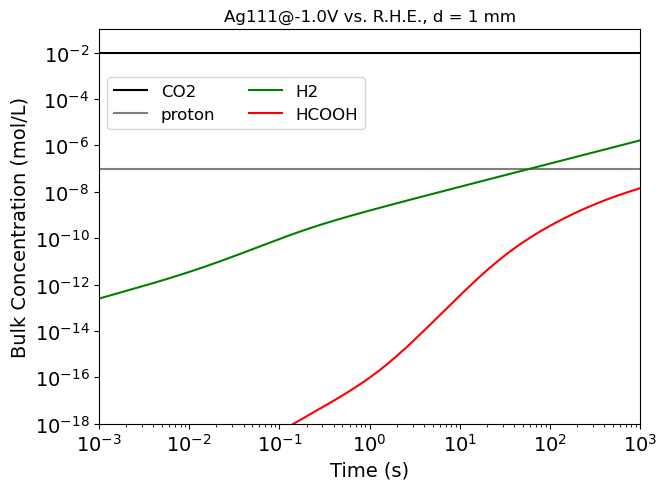

In [278]:
exclude_species = ["H2O"]
plotC_Reservoir(ssys.sims[1], conc_matrix, t_vals_2, 1e-8, exclude_species)

xscale("log")
yscale("log")
xlim(1e-3, 1e3)
ylim(1e-18, 1e-1)
legend(loc="upper left", bbox_to_anchor=(0, 0.9), fontsize=12, ncol=2)
title("Ag111@-1.0V vs. R.H.E., d = 1 mm")
gcf()

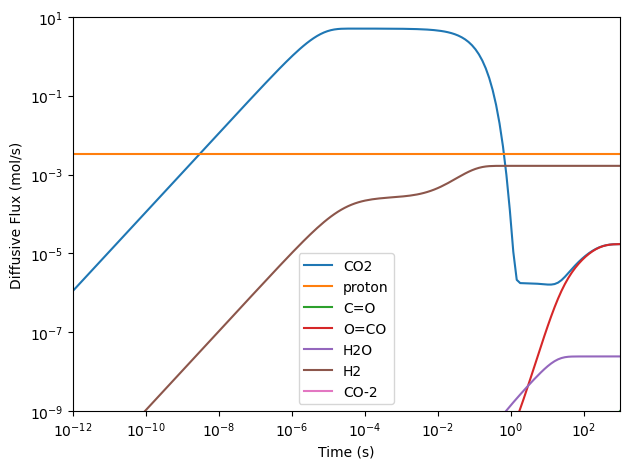

In [279]:
clf()

for i in 1:size(flux_matrix, 1)
    if maximum(abs.(flux_matrix[i, :])) > 1e-10
        plot(t_vals, abs.(flux_matrix[i, :]), label=ssys.sims[1].domain.phase.species[i].name)

    end
end

xscale("log")
yscale("log")
xlabel("Time (s)")
ylabel("Diffusive Flux (mol/s)")
xlim(1e-12, 1e3)
ylim(1e-9, 1e1)
legend()
tight_layout()
gcf()

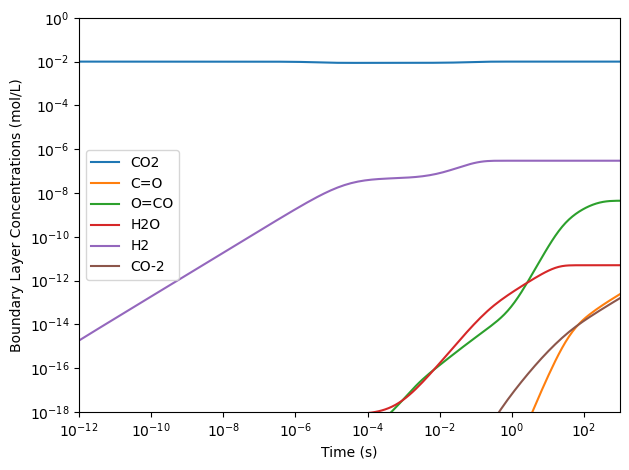

In [280]:
clf()
for i in 1:size(conc_matrix_bl, 1)
    if maximum(conc_matrix_bl[i, :]) > 1e-10
        plot(t_vals, conc_matrix_bl[i, :]/1e3, label=ssys.sims[1].domain.phase.species[i].name)

    end
end

xscale("log")
yscale("log")
xlabel("Time (s)")
ylabel("Boundary Layer Concentrations (mol/L)")
xlim(1e-12, 1e3)
ylim(1e-18, 1)
legend()
tight_layout()
gcf()

In [281]:
# Helper function
function plotX(sim, tol, t_end, exclude)
    clf()
    xs = molefractions(sim)
    maxes = maximum(xs, dims=2)

    # Filter time data up to t_end
    time_indices = findall(t -> t <= t_end, sim.sol.t)
    time_filtered = sim.sol.t[time_indices]
    xs_filtered = xs[:, time_indices]

    for i = 1:length(maxes)
        species_name = sim.domain.phase.species[i].name
        if maxes[i] > tol && !(species_name in exclude)
            plot(time_filtered, xs_filtered[i,:], label=species_name)
        end
    end
    legend()
    xlabel("Time (s)")
    ylabel("Concentration (mol/m^3)")
end

plotX (generic function with 1 method)

In [282]:
function plotC(sim, tol, t_end, exclude)
    clf()
    xs = concentrations(sim)
    maxes = maximum(xs, dims=2)

    # Filter time data up to t_end
    time_indices = findall(t -> t <= t_end, sim.sol.t)
    time_filtered = sim.sol.t[time_indices]
    xs_filtered = xs[:, time_indices]

    # Custom species order and their corresponding names and color
    species_order = ["CO2", "proton", "H2", "O=CO", "C=O", "CO-2", "CCO", "CH4", "OCO", "COC", "COCO", "CC(=O)O", "COC=O"]
    color_map = Dict("CO2" => "black", "proton" => "grey", "H2" => "green",
                        "O=CO" => "red", "C=O" => "brown", "CO-2" => "blue", "CCO" => "magenta",
                        "CH4" => "brown", "OCO" => "orange", "COC" => "teal", "COCO" => "lime", "CC(=O)O" => "teal", "COC=O" => "lime")
    # Replacement map for species labels
    replacement_map = Dict("CO-2" => "CH3OH", "O=CO" => "HCOOH", "C=O" => "HCHO",
                            "CCO" => "C2H5OH", "OCO" => "CH2(OH)2", "COC" => "CH3OCH3", "COCO" => "CH3OCH2OH", "CC(=O)O" => "CH3COOH", "COC=O" => "CH3OCHO")

    # Build a map of species names to indices
    name_to_index = Dict(sim.domain.phase.species[i].name => i for i in 1:length(sim.domain.phase.species))
    # Keep track of whether the species is plotted, used for later checks
    plotted = falses(length(sim.domain.phase.species))

    # Plot species from the custom species dictionary
    for species_name in species_order
        if species_name in exclude
            continue
        end

        if haskey(name_to_index, species_name)
            i = name_to_index[species_name]

            if (maxes[i] > tol) || (species_name == "proton") || (species_name == "CCO")  # Always plot proton and ethanol
                plot_label = get(replacement_map, species_name, species_name)
                plot_color = color_map[species_name]

                plot(time_filtered, xs_filtered[i, :]/1000, label=plot_label, color=plot_color)
                plotted[i] = true  # Mark as plotted
            end
        end
    end

    # Plot any remaining species that passed tolerance but were not in species_order
    for i in 1:length(sim.domain.phase.species)
        if plotted[i] || sim.domain.phase.species[i].name in exclude
            continue
        end

        if maxes[i] > tol
            species_name = sim.domain.phase.species[i].name
            plot(time_filtered, xs_filtered[i, :]/1000, label=species_name)  # Default color
        end
    end

    xlabel("Time (s)", fontsize=14)
    ylabel("Boundary Layer Concentration (mol/L)", fontsize=14)
    xticks(fontsize=14)
    yticks(fontsize=14)
    legend(loc="upper left", bbox_to_anchor=(0, 0.9), fontsize=12, ncol=2)
end

plotC (generic function with 1 method)

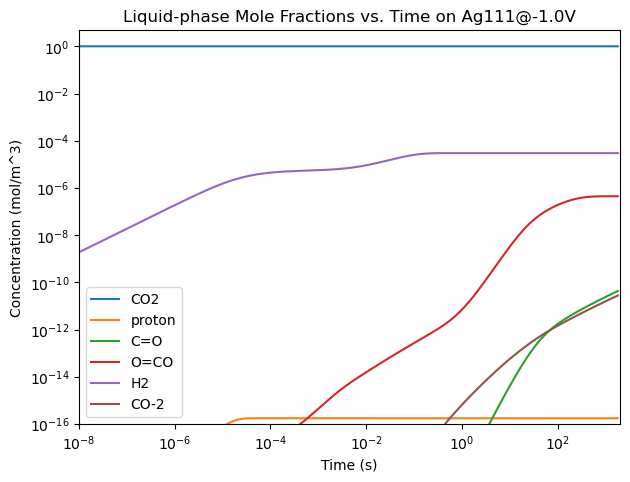

In [283]:
exclude_species = ["H2O"]
plotX(ssys.sims[1], 1e-12, 1.8e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-8, 2e3)
ylim(1e-16, 5)
title("Liquid-phase Mole Fractions vs. Time on Ag111@-1.0V")
gcf()

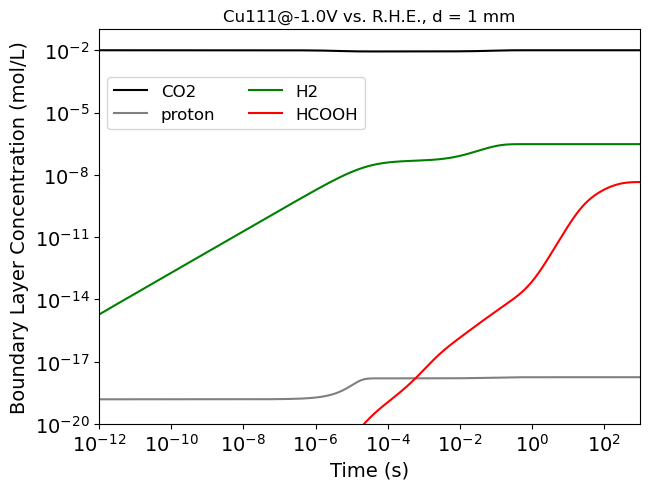

In [284]:
exclude_species = ["H2O"]
plotC(ssys.sims[1], 1e-8, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-12, 1e3)
ylim(1e-20, 1e-1)
title("Cu111@-1.0V vs. R.H.E., d = 1 mm")
gcf()

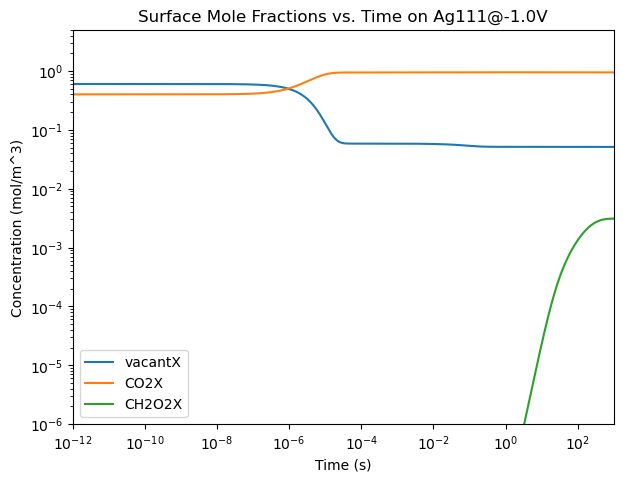

In [285]:
exclude_species = ["H2O"]
plotX(ssys.sims[2], 1e-3, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-12, 1e3)
ylim(1e-6, 5)
title("Surface Mole Fractions vs. Time on Ag111@-1.0V")
gcf()